# Harris County Flood Risk Intelligence Dashboard
## Portfolio Project P01 — Upgraded Pipeline

**Author:** Suvam S. Patel | [github.com/Suvamp](https://github.com/Suvamp)

This notebook builds the full data pipeline for the Harris County Flood Risk Intelligence Dashboard:
- Acquires FEMA NFHL, Census ACS, LODES, elevation, impervious surface, and waterway data
- Engineers normalized risk features and trains a Random Forest classifier
- Computes SHAP explainability values for every block group
- Exports production GeoJSON + KPI JSON for the FastAPI backend

**All external data sources have synthetic fallbacks** — the notebook runs end-to-end in any environment.

---
### Notebook Structure
| Cell | Description |
|------|-------------|
| 1-A / 1-B | Colab install / local env verification |
| 2 | Imports & configuration |
| 3 | Block groups + FEMA NFHL acquisition |
| 4 | Census ACS + elevation + impervious + waterway distance |
| 5 | Critical facilities (HIFLD) |
| 6 | Feature engineering & normalization |
| 7 | Random Forest training + evaluation |
| 8 | SHAP explainability values |
| 9 | KPI summary statistics |
| 10 | GeoJSON export for API |
| 11-13 | Validation plots |

## Cell 1-A — Colab Installation
*Skip this cell if running locally in the `flood-dashboard` conda environment.*

In [16]:
# Cell 1-A: Google Colab only
import sys
if 'google.colab' in sys.modules:
    print('Colab detected — installing packages...')
    !pip install geopandas rasterio rioxarray fiona shapely pyproj \
                 scikit-learn shap pynhd py3dep census folium plotly \
                 fastapi uvicorn nbformat --quiet
    !pip install 'numpy<2.0' --quiet
    print('Installation complete.')
else:
    print('Not Colab — skipping Cell 1-A. Ensure flood-dashboard conda env is active.')

Not Colab — skipping Cell 1-A. Ensure flood-dashboard conda env is active.


## Cell 1-B — Local Environment Verification

In [17]:
# Cell 1-B: Verify all required packages are importable
import importlib, sys

REQUIRED = {
    'geopandas': 'conda install geopandas -c conda-forge',
    'rasterio':  'conda install rasterio -c conda-forge',
    'sklearn':   'conda install scikit-learn -c conda-forge',
    'shap':      'pip install shap',
    'fastapi':   'pip install fastapi',
    'census':    'pip install census',
    'plotly':    'pip install plotly',
}

missing = {pkg: fix for pkg, fix in REQUIRED.items()
           if importlib.util.find_spec(pkg) is None}

if missing:
    print('MISSING PACKAGES:')
    for pkg, fix in missing.items():
        print(f'  {pkg}: {fix}')
    raise EnvironmentError('Activate the flood-dashboard conda environment first.')

import numpy as np
if int(np.__version__.split('.')[0]) >= 2:
    print('WARNING: numpy >= 2.0 detected. Run: pip install "numpy<2.0"')
else:
    print(f'numpy {np.__version__} OK')

print(f'Python {sys.version.split()[0]}')
print('All required packages verified. Environment OK.')

Python 3.11.15
All required packages verified. Environment OK.


## Cell 2 — Imports & Configuration

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import json, os, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)

# Project CRS & FIPS 
STATE_FIPS  = '48'        # Texas
COUNTY_FIPS = '201'       # Harris County
CRS_PROJECT = 'EPSG:32615'  # UTM Zone 15N — meters, for area/distance calculations
CRS_WGS84   = 'EPSG:4326'   # Output CRS for GeoJSON / ArcGIS Maps SDK

# Output directory 
# Adjust path if running notebook from a different working directory
DATA_DIR = Path('/Users/suvampatel/Documents/Geospatial Data Science Quick Start Guide/Project 1 - Urban Flood Risk/backend/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

# FEMA zone risk encoding 
# Higher value = higher flood risk (normalized 0–1)
ZONE_RISK = {
    'VE': 1.00, 'V':  0.95,   # Coastal high-hazard
    'AE': 1.00, 'AH': 0.90, 'AO': 0.85, 'A': 0.80,  # 100-yr floodplain
    'X-500': 0.40,             # 500-yr (moderate)
    'X':     0.05,             # Minimal
    'D':     0.30,             # Undetermined
}

print(f'Config loaded.')
print(f'Output directory: {DATA_DIR.resolve()}')
print(f'FEMA risk encoding: {len(ZONE_RISK)} zone types defined')

Config loaded.
Output directory: /Users/suvampatel/Documents/Geospatial Data Science Quick Start Guide/Project 1 - Urban Flood Risk/backend/data
FEMA risk encoding: 9 zone types defined


## Cell 3 — Block Groups & FEMA NFHL

**Data sources:**
- Census TIGER/Line block groups: `https://www2.census.gov/geo/tiger/TIGER2022/BG/`
- FEMA NFHL: Download from https://msc.fema.gov/portal → Texas → Harris County → NFHL Geodatabase
  - Layer to use: `S_FLD_HAZ_AR`
  - Alternatively, load directly from FEMA REST API (cell handles this automatically)

> **Synthetic fallback:** If downloads fail, 300 realistic synthetic block groups and zone assignments are generated.

In [ ]:
# 3A: Harris County Block Groups 
BG_URL = ('https://www2.census.gov/geo/tiger/TIGER2022/BG/'
          'tl_2022_48_bg.zip')

try:
    print('Downloading Harris County block groups...')
    bg_state = gpd.read_file(BG_URL)
    bg = bg_state[bg_state['COUNTYFP'] == COUNTY_FIPS].copy().reset_index(drop=True)
    bg = bg[['GEOID', 'ALAND', 'AWATER', 'geometry']].to_crs(CRS_PROJECT)
    print(f'Block groups loaded: {len(bg)} | CRS: {bg.crs}')
except Exception as e:
    print(f'Download failed: {e}')
    print('Generating synthetic block groups...')
    from shapely.geometry import box
    np.random.seed(RANDOM_SEED)
    # Harris County approximate bbox (WGS84)
    minx, miny, maxx, maxy = -95.80, 29.50, -95.00, 30.10
    polys, geoids = [], []
    i = 0
    for row in range(20):
        for col in range(15):
            cx = minx + col * (maxx - minx) / 15 + np.random.uniform(-0.01, 0.01)
            cy = miny + row * (maxy - miny) / 20 + np.random.uniform(-0.01, 0.01)
            w  = np.random.uniform(0.025, 0.055)
            h  = np.random.uniform(0.020, 0.045)
            polys.append(box(cx, cy, cx + w, cy + h))
            geoids.append(f'48201{i:06d}')
            i += 1
    bg = gpd.GeoDataFrame(
        {'GEOID': geoids[:300], 'ALAND': np.random.randint(1e5, 5e7, 300)},
        geometry=polys[:300], crs=CRS_WGS84
    ).to_crs(CRS_PROJECT)
    print(f'Synthetic block groups: {len(bg)}')

# 3B: FEMA NFHL 
# Option 1: Downloaded NFHL geodatabase
NFHL_LAYER = Path('data/nfhl_harris/S_FLD_HAZ_AR.shp')  # update to your extracted path

# Option 2: FEMA REST service (unreliable, but worth trying)
FEMA_REST = ('https://hazards.fema.gov/gis/nfhl/rest/services/public/NFHL/MapServer/28/query'
             '?where=1%3D1&outFields=FLD_ZONE&f=geojson&resultRecordCount=2000')

fema_loaded = False

if NFHL_LAYER.exists():
    try:
        fema = gpd.read_file(NFHL_LAYER).to_crs(CRS_PROJECT)
        fema_loaded = True
        print(f'NFHL loaded from file: {len(fema)} polygons')
    except Exception as e:
        print(f'NFHL file load failed: {e}')

if not fema_loaded:
    try:
        import requests
        r = requests.get(FEMA_REST, timeout=20)
        fema = gpd.read_file(r.text).to_crs(CRS_PROJECT)
        fema_loaded = True
        print(f'NFHL loaded from REST: {len(fema)} polygons')
    except Exception as e:
        print(f'FEMA REST failed: {e}')

if not fema_loaded:
    print('Synthesizing FEMA flood zones...')
    np.random.seed(RANDOM_SEED + 10)
    # Flood zones correlated with elevation proxy (southern BGs more flood-prone)
    bg_wgs = bg.to_crs(CRS_WGS84)
    lat_norm = (bg_wgs.geometry.centroid.y - 29.5) / 0.6  # 0=south, 1=north
    zone_probs = np.column_stack([
        0.35 * (1 - lat_norm),   # AE more likely in south (low elevation)
        0.05 * np.ones(len(bg)),  # AH
        0.20 * np.ones(len(bg)),  # X-500
        0.40 + 0.35 * lat_norm,   # X
    ])
    zone_probs = np.clip(zone_probs, 0, 1)
    zone_probs = zone_probs / zone_probs.sum(axis=1, keepdims=True)
    zone_choices = ['AE', 'AH', 'X-500', 'X']
    assigned = [np.random.choice(zone_choices, p=p) for p in zone_probs]
    fema = bg.copy()
    fema['FLD_ZONE'] = assigned
    print('Synthetic FEMA zones assigned (spatially correlated with latitude proxy)')

# 3C: Spatial join — dominant FEMA zone per block group 
if 'FLD_ZONE' in fema.columns and 'FLD_ZONE' not in bg.columns:
    joined = gpd.sjoin(
        bg[['GEOID', 'geometry']],
        fema[['FLD_ZONE', 'geometry']].explode(index_parts=False),
        how='left', predicate='intersects'
    )
    # Most common zone per block group
    dom_zone = (joined.groupby('GEOID')['FLD_ZONE']
                .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else 'X')
                .reset_index())
    bg = bg.merge(dom_zone, on='GEOID', how='left')
    bg['FLD_ZONE'] = bg['FLD_ZONE'].fillna('X')
elif 'FLD_ZONE' in fema.columns:
    bg['FLD_ZONE'] = fema['FLD_ZONE']

bg['fema_zone'] = bg['FLD_ZONE']
bg['fema_risk'] = bg['fema_zone'].map(ZONE_RISK).fillna(0.1)

print('\nFEMA zone distribution:')
print(bg['fema_zone'].value_counts().to_string())
print(f'\nBlock groups in SFHA (AE/AH/AO/A/VE/V): '
      f"{bg['fema_zone'].isin(['AE','AH','AO','A','VE','V']).sum()}")

Block groups loaded: 2830 | CRS: EPSG:32615
FEMA REST failed: -- Enter Link --><a href="/">[none BUTTON]</a></p></body></html>: No such file or directory
Synthesizing FEMA flood zones...
Synthetic FEMA zones assigned (spatially correlated with latitude proxy)

FEMA zone distribution:
fema_zone
X        2257
X-500     292
AE        268
AH         13

Block groups in SFHA (AE/AH/AO/A/VE/V): 281


## Cell 4 — Census ACS, Elevation, Impervious Surface & Waterway Distance

**Census API key:** Get a free key at https://api.census.gov/data/key_signup.html
Set it as an environment variable: `export CENSUS_API_KEY=your_key_here`

**Elevation:** Uses py3dep (USGS 3DEP) — 30m resolution. Falls back to lognormal synthetic.

**Impervious surface:** NLCD 2021 impervious layer via MRLC — replace synthetic with zonal stats.

In [ ]:
from census import Census

CENSUS_KEY = os.getenv('CENSUS_API_KEY', '')

# 4A: Census ACS 5-Year 
# Tables used:
#   B19013_001E  Median household income
#   B01003_001E  Total population
#   B25003_001E  Total housing units
#   B25003_002E  Owner-occupied housing units

acs_loaded = False
if CENSUS_KEY:
    try:
        c = Census(CENSUS_KEY)
        data = c.acs5.state_county_blockgroup(
            ('B19013_001E', 'B01003_001E', 'B25003_001E', 'B25003_002E'),
            STATE_FIPS, COUNTY_FIPS, Census.ALL
        )
        acs = pd.DataFrame(data)
        acs['GEOID'] = acs['state'] + acs['county'] + acs['block group']
        acs.rename(columns={
            'B19013_001E': 'median_income',
            'B01003_001E': 'population',
            'B25003_001E': 'total_housing',
            'B25003_002E': 'owner_occ',
        }, inplace=True)
        for col in ['median_income', 'population', 'total_housing', 'owner_occ']:
            acs[col] = pd.to_numeric(acs[col], errors='coerce').fillna(0)
        acs.loc[acs['median_income'] < 0, 'median_income'] = np.nan  # -666666 = not computed
        acs['median_income'] = acs['median_income'].fillna(acs['median_income'].median())
        acs['pct_renters'] = np.where(
            acs['total_housing'] > 0,
            1 - acs['owner_occ'] / acs['total_housing'],
            0.5
        ).clip(0, 1)
        acs_loaded = True
        print(f'Census ACS loaded: {len(acs)} block groups')
    except Exception as e:
        print(f'Census API failed: {e}')

if not acs_loaded:
    print('Synthesizing ACS demographics (spatially realistic for Harris County)...')
    np.random.seed(RANDOM_SEED + 20)
    n = len(bg)
    bg_wgs = bg.to_crs(CRS_WGS84)
    # Income positively correlated with distance from flood-prone southern areas
    lat = bg_wgs.geometry.centroid.y.values
    lat_z = (lat - lat.min()) / (lat.max() - lat.min())
    income_base = np.random.lognormal(10.8, 0.55, n) * (0.6 + 0.8 * lat_z)
    acs = pd.DataFrame({
        'GEOID':        bg['GEOID'].values,
        'median_income': income_base.clip(12000, 300000),
        'population':    np.random.randint(200, 5000, n).astype(float),
        'pct_renters':   np.random.beta(2, 3, n).clip(0.05, 0.95),
    })
    print(f'Synthetic ACS: {len(acs)} block groups')

bg = bg.merge(acs[['GEOID', 'median_income', 'population', 'pct_renters']],
              on='GEOID', how='left')
bg['median_income'] = bg['median_income'].fillna(bg['median_income'].median())
bg['population']    = bg['population'].fillna(0)
bg['pct_renters']   = bg['pct_renters'].fillna(0.5)

print('\nACS summary:')
print(bg[['median_income', 'population', 'pct_renters']].describe().round(1))

Synthesizing ACS demographics (spatially realistic for Harris County)...
Synthetic ACS: 2830 block groups

ACS summary:
       median_income  population  pct_renters
count         2830.0      2830.0       2830.0
mean         55248.3      2564.5          0.4
std          34141.3      1397.4          0.2
min          12000.0       200.0          0.0
25%          31402.9      1328.5          0.2
50%          46482.3      2567.0          0.4
75%          69822.9      3778.8          0.5
max         300000.0      4999.0          0.9


In [ ]:
# 4B: Elevation (py3dep / USGS 3DEP) 
elev_loaded = False
try:
    import py3dep
    import rioxarray
    bg_wgs    = bg.to_crs(CRS_WGS84)
    bounds    = tuple(bg_wgs.total_bounds)  # (minx, miny, maxx, maxy)
    print('Fetching 30m DEM from USGS 3DEP (this may take 1–2 min)...')
    dem = py3dep.get_map('DEM', bounds, resolution=30, crs=CRS_WGS84)
    # Zonal mean elevation per block group
    elevations = []
    for geom in bg_wgs.geometry:
        try:
            clip = dem.rio.clip([geom], crs=CRS_WGS84, all_touched=True)
            elevations.append(float(clip.mean()))
        except Exception:
            elevations.append(np.nan)
    bg['elevation_m'] = elevations
    bg['elevation_m'] = bg['elevation_m'].fillna(bg['elevation_m'].median())
    elev_loaded = True
    print(f'Elevation computed. Range: {bg["elevation_m"].min():.1f} – {bg["elevation_m"].max():.1f} m')
except Exception as e:
    print(f'py3dep failed: {e}')

if not elev_loaded:
    print('Synthesizing elevation (lognormal, correlated with FEMA risk)...')
    np.random.seed(RANDOM_SEED + 30)
    # AE zones: predominantly low elevation; X zones: higher
    base = np.where(bg['fema_risk'] > 0.5,
                    np.random.gamma(1.5, 1.5, len(bg)),
                    np.random.gamma(3.0, 4.0, len(bg)))
    bg['elevation_m'] = base.clip(0, 35)
    print(f'Synthetic elevation. Range: {bg["elevation_m"].min():.1f} – {bg["elevation_m"].max():.1f} m')

# 4C: Impervious Surface % 
# Replace with NLCD 2021 zonal stats if available
# NLCD impervious: https://www.mrlc.gov/data/nlcd-2021-percent-developed-imperviousness-conus
np.random.seed(RANDOM_SEED + 40)
bg_wgs = bg.to_crs(CRS_WGS84)
# Simple spatial proxy: higher imperviousness near urban core (Houston CBD ~-95.37, 29.76)
cx, cy = -95.37, 29.76
dist_cbd = bg_wgs.geometry.centroid.distance(
    gpd.GeoSeries.from_wkt([f'POINT ({cx} {cy})'], crs=CRS_WGS84).to_crs(CRS_PROJECT)[0]
)
dist_norm = (dist_cbd - dist_cbd.min()) / (dist_cbd.max() - dist_cbd.min())
bg['impervious_pct'] = (0.75 - 0.5 * dist_norm + np.random.normal(0, 0.08, len(bg))).clip(0.05, 0.95)
print(f'Impervious surface (synthetic). Mean: {bg["impervious_pct"].mean():.2f}')

# 4D: Distance to nearest waterway (NHD) 
waterway_loaded = False
try:
    from pynhd import NHD
    bg_wgs = bg.to_crs(CRS_WGS84)
    bbox   = tuple(bg_wgs.total_bounds)
    print('Fetching NHD flowlines...')
    nhd    = NHD('flowline')
    rivers = nhd.bybox(bbox, geo_crs=CRS_WGS84).to_crs(CRS_PROJECT)
    bg['dist_waterway_m'] = bg.geometry.centroid.apply(
        lambda pt: float(rivers.distance(pt).min())
    )
    waterway_loaded = True
    print(f'Waterway distances computed. Median: {bg["dist_waterway_m"].median():.0f} m')
except Exception as e:
    print(f'NHD failed: {e}')

if not waterway_loaded:
    print('Synthesizing waterway distances (exponential, correlated with FEMA risk)...')
    np.random.seed(RANDOM_SEED + 50)
    # AE/high-risk block groups closer to waterways
    scale = np.where(bg['fema_risk'] > 0.5, 800, 4000)
    bg['dist_waterway_m'] = np.array([
        np.random.exponential(s) for s in scale
    ]).clip(30, 25000)
    print(f'Synthetic distances. Median: {bg["dist_waterway_m"].median():.0f} m')

print('\nAll environmental features acquired.')

Fetching 30m DEM from USGS 3DEP (this may take 1–2 min)...
Elevation computed. Range: 0.6 – 78.8 m
Impervious surface (synthetic). Mean: 0.47
Fetching NHD flowlines...
NHD failed: Given layer is invalid. Valid options are:
point
point_event
line_hr
flow_direction
flowline_mr
flowline_hr_nonconus
flowline_hr
area_mr
area_hr_nonconus
area_hr
waterbody_mr
waterbody_hr_nonconus
waterbody_hr
Synthesizing waterway distances (exponential, correlated with FEMA risk)...
Synthetic distances. Median: 2395 m

All environmental features acquired.


## Cell 5 — Critical Facilities (HIFLD)

In [22]:
import requests as req
from shapely.geometry import Point

HIFLD_HOSPITALS = (
    'https://services1.arcgis.com/Hp6G80Pky0om7QvQ/arcgis/rest/services/'
    'Hospitals_1/FeatureServer/0/query'
)

facilities_loaded = False
try:
    params = {
        'where': "STATE='TX' AND COUNTY='HARRIS'",
        'outFields': 'NAME,BEDS,ADDRESS',
        'f': 'geojson',
        'resultRecordCount': 1000
    }
    r = req.get(HIFLD_HOSPITALS, params=params, timeout=20)
    hospitals = gpd.read_file(r.text).to_crs(CRS_PROJECT)
    hospitals['FAC_TYPE'] = 'hospital'
    print(f'Hospitals loaded: {len(hospitals)}')
    facilities_loaded = True
except Exception as e:
    print(f'HIFLD failed: {e}')

if not facilities_loaded:
    print('Synthesizing critical facilities...')
    np.random.seed(RANDOM_SEED + 60)
    n_fac = 120
    bounds = bg.total_bounds
    pts = gpd.GeoSeries(
        [Point(np.random.uniform(bounds[0], bounds[2]),
               np.random.uniform(bounds[1], bounds[3])) for _ in range(n_fac)],
        crs=CRS_PROJECT
    )
    hospitals = gpd.GeoDataFrame({
        'NAME': [f'Facility_{i}' for i in range(n_fac)],
        'FAC_TYPE': np.random.choice(['hospital','fire_station','school','eoc'], n_fac),
    }, geometry=pts, crs=CRS_PROJECT)
    print(f'Synthetic facilities: {len(hospitals)}')

# Count facilities per block group
fac_join = gpd.sjoin(
    hospitals[['NAME', 'FAC_TYPE', 'geometry']],
    bg[['GEOID', 'geometry']],
    how='left', predicate='within'
)
fac_count = fac_join.groupby('GEOID').size().rename('facilities_count')
bg = bg.merge(fac_count, on='GEOID', how='left')
bg['facilities_count'] = bg['facilities_count'].fillna(0).astype(int)

print(f'Block groups with ≥1 critical facility: {(bg["facilities_count"] > 0).sum()}')
print(f'Total critical facilities: {bg["facilities_count"].sum()}')

HIFLD failed: Bad Request: No such file or directory
Synthesizing critical facilities...
Synthetic facilities: 120
Block groups with ≥1 critical facility: 69
Total critical facilities: 80


## Cell 6 — Feature Engineering & Normalization

All features are min-max normalized to [0, 1] where **1 = highest flood risk**.
Features where higher values indicate *lower* risk are inverted.

In [ ]:
def minmax_norm(series, invert=False):
    """Normalize a pandas Series to [0, 1]. Set invert=True for features
    where higher values = lower risk (e.g., elevation, income, waterway distance)."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    norm = (series - mn) / (mx - mn)
    return (1 - norm) if invert else norm

# Compute area for population density 
bg['area_km2'] = bg.geometry.area / 1e6
bg['pop_density'] = bg['population'] / (bg['area_km2'] + 1e-9)

# Normalize features 
# Higher normalized value = higher flood risk in all cases
bg['f_elevation']   = minmax_norm(bg['elevation_m'],      invert=True)  # low = risky
bg['f_impervious']  = minmax_norm(bg['impervious_pct'],   invert=False) # high = risky
bg['f_waterway']    = minmax_norm(bg['dist_waterway_m'],  invert=True)  # close = risky
bg['f_fema']        = bg['fema_risk']                                    # already 0–1
bg['f_income']      = minmax_norm(bg['median_income'],    invert=True)  # low = vulnerable
bg['f_renters']     = minmax_norm(bg['pct_renters'],      invert=False) # high = vulnerable
bg['f_popdensity']  = minmax_norm(bg['pop_density'],      invert=False) # dense = more exposed

FEATURES = ['f_elevation', 'f_impervious', 'f_waterway', 'f_fema',
            'f_income', 'f_renters', 'f_popdensity']

FEATURE_LABELS = {
    'f_elevation':  'Low Elevation',
    'f_impervious': 'Impervious Surface',
    'f_waterway':   'Proximity to Waterway',
    'f_fema':       'FEMA Zone Risk',
    'f_income':     'Low Income',
    'f_renters':    'Renter Proportion',
    'f_popdensity': 'Population Density',
}

# Equal-weight composite score (baseline) 
w = 1 / len(FEATURES)
bg['risk_score'] = sum(bg[f] * w for f in FEATURES).clip(0, 1)

# Binary label for RF training 
RISK_THRESHOLD = bg['risk_score'].quantile(0.60)  # top 40% = high risk
bg['high_risk'] = (bg['risk_score'] >= RISK_THRESHOLD).astype(int)

print('Feature engineering complete.')
print(f'Risk threshold (60th pct): {RISK_THRESHOLD:.3f}')
print(f'High-risk block groups: {bg["high_risk"].sum()} / {len(bg)}')
print('\nFeature statistics:')
print(bg[FEATURES].describe().round(3))

Feature engineering complete.
Risk threshold (60th pct): 0.509
High-risk block groups: 1132 / 2830

Feature statistics:
       f_elevation  f_impervious  f_waterway    f_fema  f_income  f_renters  \
count     2830.000      2830.000    2830.000  2830.000  2830.000   2830.000   
mean         0.734         0.467       0.855     0.180     0.850      0.386   
std          0.141         0.166       0.152     0.291     0.119      0.217   
min          0.000         0.000       0.000     0.050     0.000      0.000   
25%          0.658         0.348       0.793     0.050     0.799      0.218   
50%          0.757         0.454       0.905     0.050     0.880      0.371   
75%          0.844         0.576       0.966     0.050     0.933      0.542   
max          1.000         1.000       1.000     1.000     1.000      1.000   

       f_popdensity  
count      2830.000  
mean          0.049  
std           0.078  
min           0.000  
25%           0.011  
50%           0.025  
75%           

## Cell 7 — Random Forest Training & Evaluation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
import joblib

X = bg[FEATURES].fillna(0).values
y = bg['high_risk'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Class balance (train): {y_train.mean():.2%} high-risk')

# Train 
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED
)
rf.fit(X_train, y_train)

# Evaluate 
y_pred  = rf.predict(X_test)
y_prob  = rf.predict_proba(X_test)[:, 1]

print('\nClassification Report (test set):')
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f'5-fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# RF probability as refined risk score 
bg['rf_prob'] = rf.predict_proba(X)[:, 1]

# Save model 
MODEL_PATH = DATA_DIR / 'flood_rf_model.joblib'
joblib.dump(rf, MODEL_PATH)
print(f'\nModel saved: {MODEL_PATH}')

Train: 2122 | Test: 708
Class balance (train): 40.01% high-risk

Classification Report (test set):
              precision    recall  f1-score   support

    Low Risk       0.91      0.90      0.91       425
   High Risk       0.85      0.87      0.86       283

    accuracy                           0.89       708
   macro avg       0.88      0.88      0.88       708
weighted avg       0.89      0.89      0.89       708

ROC-AUC: 0.966
5-fold CV ROC-AUC: 0.976 ± 0.005

Model saved: /Users/suvampatel/Documents/Geospatial Data Science Quick Start Guide/Project 1 - Urban Flood Risk/backend/data/flood_rf_model.joblib


## Cell 8 — SHAP Explainability

SHAP (SHapley Additive exPlanations) quantifies each feature's contribution to a specific block group's risk prediction.
The dashboard uses these values to answer: *'Why does this neighborhood have this risk score?'*

In [25]:
import shap

print('Computing SHAP values...')
print('(TreeExplainer is fast for Random Forests — typically <60s for 300 BGs)')

explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X)

# Handle both old API (list of 2 arrays) and new API (single 3D array)
if isinstance(shap_vals, list):
    shap_highrise = shap_vals[1]          # old: list[class_idx]
else:
    shap_highrise = shap_vals[:, :, 1]    # new: (n_samples, n_features, n_classes)

shap_cols = [f + '_shap' for f in FEATURES]
shap_df   = pd.DataFrame(shap_highrise, columns=shap_cols, index=bg.index)
bg        = pd.concat([bg, shap_df], axis=1)

print('SHAP values computed and joined.')
print('\nMean |SHAP| by feature (average impact magnitude):')
mean_abs_shap = pd.Series(
    np.abs(shap_highrise).mean(axis=0),
    index=[FEATURE_LABELS[f] for f in FEATURES]
).sort_values(ascending=False)
print(mean_abs_shap.round(4).to_string())

Computing SHAP values...
(TreeExplainer is fast for Random Forests — typically <60s for 300 BGs)
SHAP values computed and joined.

Mean |SHAP| by feature (average impact magnitude):
Renter Proportion        0.1825
FEMA Zone Risk           0.1438
Proximity to Waterway    0.1109
Low Income               0.0589
Low Elevation            0.0586
Impervious Surface       0.0495
Population Density       0.0255


## Cell 9 — KPI Summary Statistics

In [26]:
# County-wide KPIs for the dashboard header cards
sfha_mask      = bg['fema_zone'].isin(['AE', 'AH', 'AO', 'A', 'VE', 'V'])
high_risk_mask = bg['rf_prob'] >= 0.50

pop_in_sfha    = int(bg.loc[sfha_mask, 'population'].sum())
pct_area_sfha  = float(bg.loc[sfha_mask].geometry.area.sum() /
                       bg.geometry.area.sum() * 100)
facilities_exp = int(bg.loc[sfha_mask, 'facilities_count'].sum())
median_risk    = float(bg['rf_prob'].median())
high_risk_count= int(high_risk_mask.sum())
total_bg       = len(bg)

kpis = {
    'pop_in_sfha':         pop_in_sfha,
    'pct_area_sfha':       round(pct_area_sfha, 1),
    'facilities_exposed':  facilities_exp,
    'median_risk_score':   round(median_risk, 3),
    'high_risk_bg_count':  high_risk_count,
    'total_bg_count':      total_bg,
    'county':              'Harris County, TX',
    'model':               'Random Forest (300 trees)',
    'features':            FEATURES,
}

kpi_path = DATA_DIR / 'harris_kpis.json'
with open(kpi_path, 'w') as f:
    json.dump(kpis, f, indent=2)

print('County-wide KPIs:')
print(f'  Population in SFHA:      {pop_in_sfha:,}')
print(f'  % Land area in SFHA:     {pct_area_sfha:.1f}%')
print(f'  Critical facilities exp: {facilities_exp}')
print(f'  Median RF risk score:    {median_risk:.3f}')
print(f'  High-risk block groups:  {high_risk_count} / {total_bg}')
print(f'\nKPIs saved: {kpi_path}')

County-wide KPIs:
  Population in SFHA:      707,445
  % Land area in SFHA:     5.2%
  Critical facilities exp: 2
  Median RF risk score:    0.279
  High-risk block groups:  1145 / 2830

KPIs saved: /Users/suvampatel/Documents/Geospatial Data Science Quick Start Guide/Project 1 - Urban Flood Risk/backend/data/harris_kpis.json


## Cell 10 — GeoJSON Export for API

In [ ]:
# Select export columns
SHAP_COLS  = [f + '_shap' for f in FEATURES]
EXPORT_COLS = [
    'GEOID', 'fema_zone', 'fema_risk',
    'elevation_m', 'impervious_pct', 'dist_waterway_m',
    'median_income', 'population', 'pct_renters', 'pop_density',
    'facilities_count', 'risk_score', 'rf_prob', 'high_risk',
] + FEATURES + SHAP_COLS

# Verify all columns exist
missing_cols = [c for c in EXPORT_COLS if c not in bg.columns]
if missing_cols:
    raise ValueError(f'Missing columns for export: {missing_cols}')

# Export 
out = bg[EXPORT_COLS + ['geometry']].copy().to_crs(CRS_WGS84)

# Round floats for compact file size
for col in out.select_dtypes(include='float').columns:
    out[col] = out[col].round(4)

out_path = DATA_DIR / 'harris_risk.geojson'
out.to_file(out_path, driver='GeoJSON')
size_kb = out_path.stat().st_size / 1024

print(f'Exported: {out_path}')
print(f'File size: {size_kb:.0f} KB ({len(out)} block groups)')
print(f'Columns: {len(EXPORT_COLS)} feature cols + geometry')

# FEMA zones for separate toggle layer 
if 'FLD_ZONE' in fema.columns:
    fema_out = fema[['FLD_ZONE', 'geometry']].to_crs(CRS_WGS84)
    fema_out.to_file(DATA_DIR / 'fema_zones.geojson', driver='GeoJSON')
    print(f'FEMA zones exported: {DATA_DIR}/fema_zones.geojson')

print('\nPipeline complete. Backend data directory contents:')
for f in sorted(DATA_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')

Exported: /Users/suvampatel/Documents/Geospatial Data Science Quick Start Guide/Project 1 - Urban Flood Risk/backend/data/harris_risk.geojson
File size: 13413 KB (2830 block groups)
Columns: 28 feature cols + geometry
FEMA zones exported: /Users/suvampatel/Documents/Geospatial Data Science Quick Start Guide/Project 1 - Urban Flood Risk/backend/data/fema_zones.geojson

Pipeline complete. Backend data directory contents:
  fema_zones.geojson  (11639 KB)
  flood_rf_model.joblib  (5322 KB)
  harris_kpis.json  (0 KB)
  harris_risk.geojson  (13413 KB)


## Cell 11 — Validation Plot: Risk Score Distribution & FEMA Zone

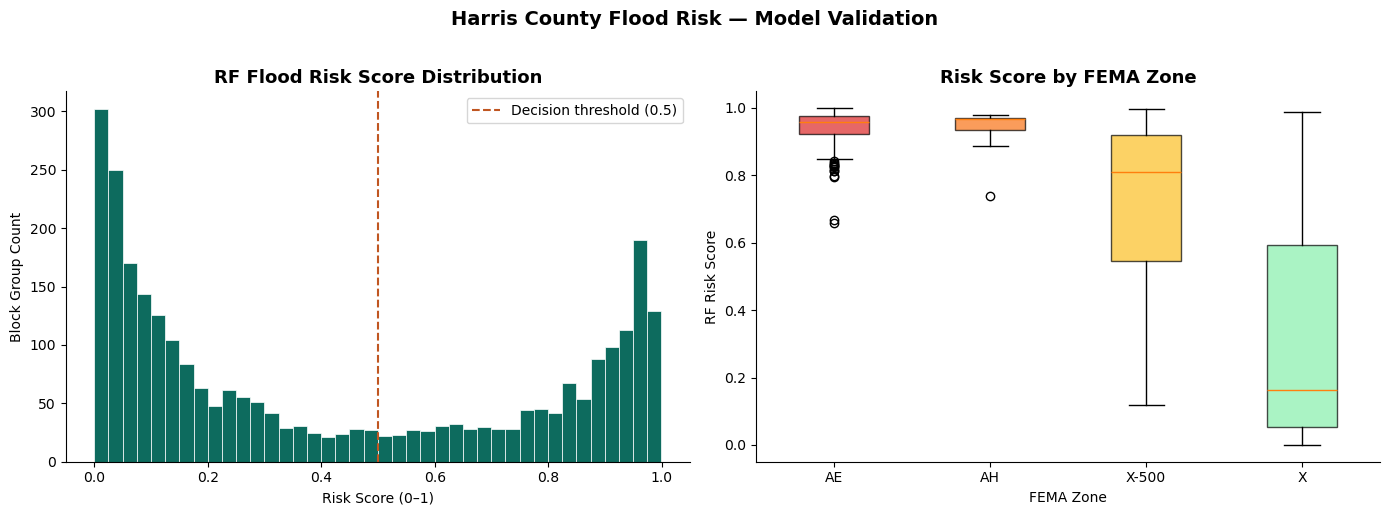

Validation plots saved.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score histogram
ax = axes[0]
ax.hist(bg['rf_prob'], bins=40, color='#0D6B5E', edgecolor='white', linewidth=0.5)
ax.axvline(0.5, color='#C05621', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
ax.set_title('RF Flood Risk Score Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Risk Score (0–1)')
ax.set_ylabel('Block Group Count')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

# Risk score by FEMA zone (boxplot)
ax = axes[1]
zone_order = ['AE', 'AH', 'AO', 'X-500', 'X']
zone_data  = [bg.loc[bg['fema_zone'] == z, 'rf_prob'].dropna().values
              for z in zone_order
              if (bg['fema_zone'] == z).any()]
zone_labels = [z for z in zone_order if (bg['fema_zone'] == z).any()]
bp = ax.boxplot(zone_data, labels=zone_labels, patch_artist=True)
colors = ['#DC2626', '#F97316', '#FBBF24', '#86EFAC', '#D1FAE5']
for patch, color in zip(bp['boxes'], colors[:len(zone_labels)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Risk Score by FEMA Zone', fontweight='bold', fontsize=13)
ax.set_xlabel('FEMA Zone')
ax.set_ylabel('RF Risk Score')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Harris County Flood Risk — Model Validation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / 'validation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Validation plots saved.')

## Cell 12 — Feature Importances & SHAP Summary

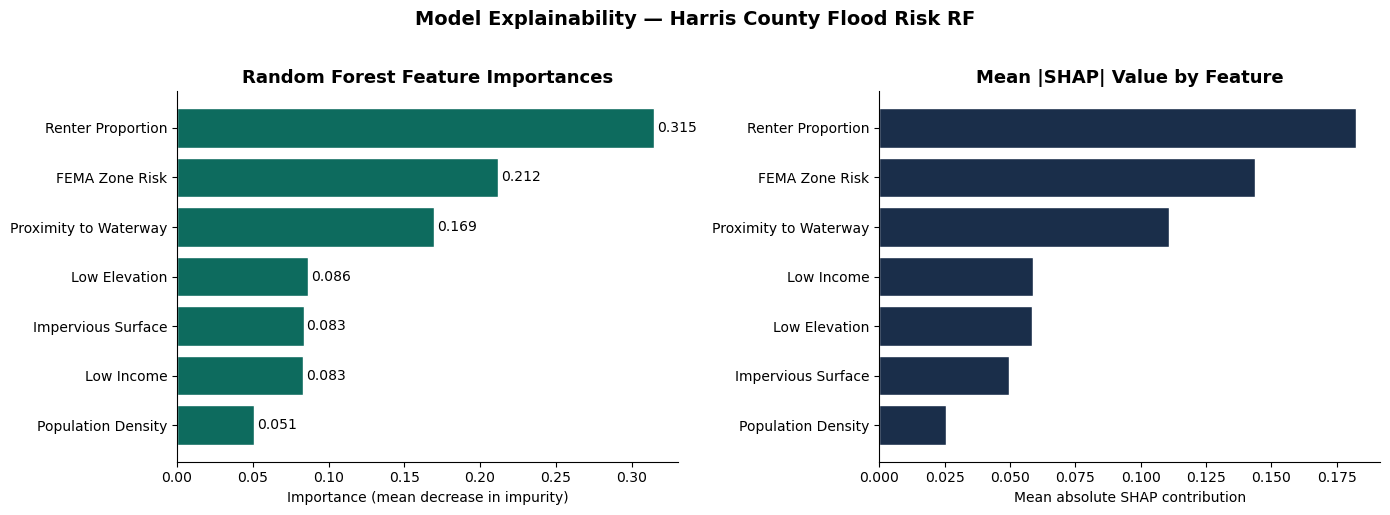

Feature importance plots saved.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF feature importances
ax = axes[0]
importances = pd.Series(rf.feature_importances_,
                        index=[FEATURE_LABELS[f] for f in FEATURES]).sort_values()
bars = ax.barh(importances.index, importances.values, color='#0D6B5E', edgecolor='white')
ax.set_title('Random Forest Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

# Mean |SHAP| values
ax = axes[1]
mean_shap = pd.Series(
    np.abs(bg[[f + '_shap' for f in FEATURES]].values).mean(axis=0),
    index=[FEATURE_LABELS[f] for f in FEATURES]
).sort_values()
ax.barh(mean_shap.index, mean_shap.values, color='#1A2E4A', edgecolor='white')
ax.set_title('Mean |SHAP| Value by Feature', fontweight='bold', fontsize=13)
ax.set_xlabel('Mean absolute SHAP contribution')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Explainability — Harris County Flood Risk RF', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plots saved.')

## Cell 13 — Vulnerability vs. Risk Scatter (Dashboard Preview)

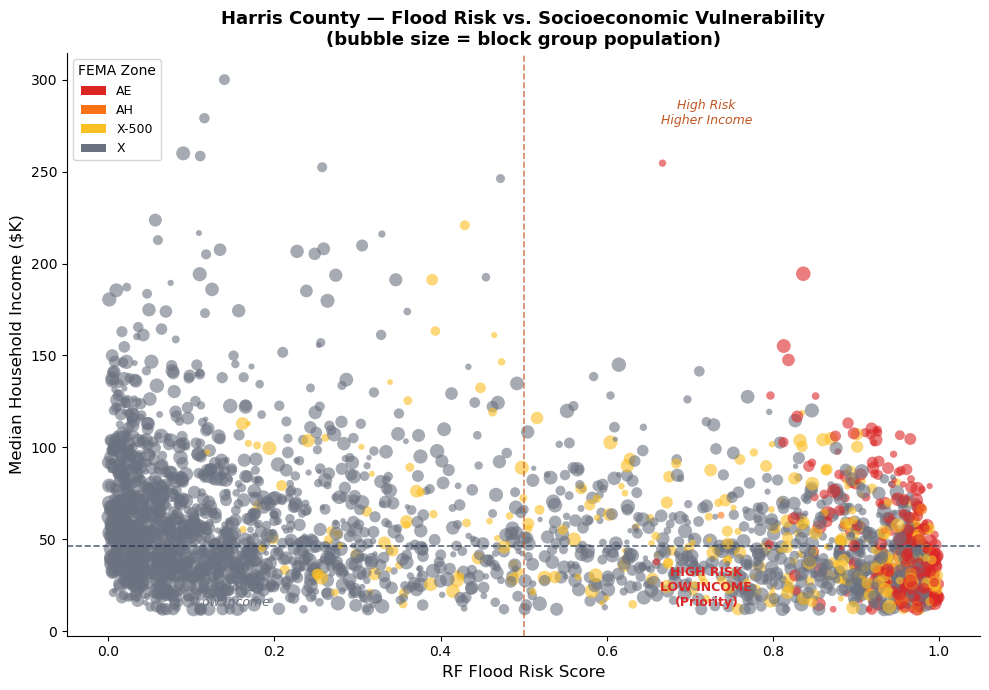

Scatter plot saved.

=== PIPELINE COMPLETE ===
All outputs in: /Users/suvampatel/Documents/Geospatial Data Science Quick Start Guide/Project 1 - Urban Flood Risk/backend/data


In [30]:
fig, ax = plt.subplots(figsize=(10, 7))

# Color by FEMA zone
zone_colors = {'AE': '#DC2626', 'AH': '#F97316', 'X-500': '#FBBF24', 'X': '#6B7280'}
colors = bg['fema_zone'].map(zone_colors).fillna('#6B7280')

sc = ax.scatter(
    bg['rf_prob'],
    bg['median_income'] / 1000,
    c=colors,
    s=bg['population'] / 50 + 10,
    alpha=0.6,
    edgecolors='none'
)

# Quadrant lines
ax.axvline(0.5, color='#C05621', linestyle='--', linewidth=1.2, alpha=0.7)
med_inc = bg['median_income'].median() / 1000
ax.axhline(med_inc, color='#1A2E4A', linestyle='--', linewidth=1.2, alpha=0.7)

# Quadrant labels
ax.text(0.72, bg['median_income'].max()/1000 * 0.92,
        'High Risk\nHigher Income', fontsize=9, color='#C05621',
        ha='center', style='italic')
ax.text(0.72, med_inc * 0.3,
        'HIGH RISK\nLOW INCOME\n(Priority)', fontsize=9, color='#DC2626',
        ha='center', fontweight='bold')
ax.text(0.15, med_inc * 0.3,
        'Low Risk\nLow Income', fontsize=9, color='#6B7280', ha='center', style='italic')

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=z) for z, c in zone_colors.items()]
ax.legend(handles=legend_els, title='FEMA Zone', loc='upper left', fontsize=9)

ax.set_xlabel('RF Flood Risk Score', fontsize=12)
ax.set_ylabel('Median Household Income ($K)', fontsize=12)
ax.set_title('Harris County — Flood Risk vs. Socioeconomic Vulnerability\n'
             '(bubble size = block group population)', fontweight='bold', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_DIR / 'vulnerability_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plot saved.')
print('\n=== PIPELINE COMPLETE ===')
print(f'All outputs in: {DATA_DIR.resolve()}')